# Time series 9: Tensor CP decomposition + LSTM (spectrum occupancy learning)

Implements the approach from **Alkhouri et al. (2020)** — *Large-Scale Spectrum Occupancy Learning via Tensor Decomposition and LSTM Networks* (IEEE).

- **Tensor representation**: Spectrum data is arranged as a **3-way tensor** X ∈ R^{F×T×N}: F = frequency channels, T = time slots per day (e.g. 24 hours), N = number of days.
- **CP decomposition**: Tensor is factorized as X ≈ ⟨A, B, C⟩ (CANDECOMP/PARAFAC). Factor **C** (N×R) carries the long-term temporal pattern over days; each column is a "basic" time series.
- **Prediction**: Fit CP on the **learning tensor** (first N_L days) to get A, B, C_L. Use **LSTM** to predict the future C factors C_P (next N_P days) from C_L. Reconstruct predicted tensor as ⟨A, B, [C_L; C_P]⟩.
- **Benefits**: Prediction is done in low-dimensional factor space (R time series instead of F×T), reducing cost and capturing long-lag correlations; robust to noise and missing entries (optional completion loop).
- **Evaluation**: Normalized prediction error (paper: e_p = √(Σ(x_i − x̂_i)² / Σ x_i²)).

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd

_root = Path.cwd().resolve()
if _root.name == "time_series":
    _root = _root.parent
DATA_PATH = _root / "data" / "transformed" / "transformed_data.parquet"
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix(".csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Transform data not found at {DATA_PATH}. Run task transform first.")

df = pd.read_parquet(DATA_PATH) if DATA_PATH.suffix == ".parquet" else pd.read_csv(DATA_PATH)
df = df.sort_values(["date", "hour"]).reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="h")

freq_bands = sorted([c for c in df.columns if c not in ("date", "hour", "datetime")])
F = len(freq_bands)  # frequency channels

Z = df[freq_bands].values.astype(np.float64)
Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Loaded {len(df)} rows. Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Channels (F): {F}")
print(f"Matrix shape: (T_total, F) = {Z.shape}")

Loaded 9192 rows. Date range: 2025-01-01 to 2026-01-18
Channels (F): 70
Matrix shape: (T_total, F) = (9192, 70)


## Reshape to 3-way tensor (F × T × N)

Paper: F = frequency bins, T = time slots per day (e.g. 10 per hour × 24 = 240, or we use **24 hours**), N = number of days. We have one row per (date, hour), so we reshape into **days × 24 × channels**, then transpose to **(F, T, N)** = (channels, 24, days).

In [26]:
T_per_day = 24  # hours per day

# Require complete days only
df["day_idx"] = (df["datetime"] - df["datetime"].min()).dt.days
rows_per_day = df.groupby("day_idx").size()
complete_days = rows_per_day[rows_per_day >= T_per_day].index.tolist()
if len(complete_days) < 2:
    raise ValueError("Need at least 2 complete days of data (24 hours each).")

df_sel = df[df["day_idx"].isin(complete_days)].sort_values(["day_idx", "hour"])
n_days = df_sel["day_idx"].nunique()

# Build tensor: for each day, take first T_per_day rows (hours 0..23)
tensor_list = []
for day, grp in df_sel.groupby("day_idx"):
    block = grp.head(T_per_day)[freq_bands].values  # (T_per_day, F)
    if len(block) < T_per_day:
        continue
    tensor_list.append(block.T)  # (F, T_per_day)

# Stack: (F, T_per_day, N)
X_tensor = np.stack(tensor_list, axis=2).astype(np.float64)
F, T, N = X_tensor.shape

print(f"Tensor shape (F, T, N) = ({F}, {T}, {N})")
print(f"F = channels, T = hours per day, N = days")

Tensor shape (F, T, N) = (70, 24, 383)
F = channels, T = hours per day, N = days


## Train / validation / test split (6 : 1 : 3)

60% of days for learning (N_L), 10% for validation (N_V), 30% for prediction/test (N_P). CP and LSTM use the learning tensor; evaluation uses the test slice.

In [27]:
train_ratio, val_ratio, test_ratio = 0.6, 0.1, 0.3
N_L = max(2, int(N * train_ratio))
N_V = int(N * val_ratio)
N_P = max(1, N - N_L - N_V)  # at least 1 day for prediction
N_V = N - N_L - N_P  # rebalance so N_L + N_V + N_P = N

X_learn = X_tensor[:, :, :N_L]   # (F, T, N_L)
X_val = X_tensor[:, :, N_L:N_L + N_V]   # (F, T, N_V) — validation
X_pred_true = X_tensor[:, :, N_L + N_V:]  # (F, T, N_P) — ground truth for evaluation

print(f"Learning tensor: (F, T, N_L) = ({F}, {T}, {N_L})")
print(f"Validation: N_V = {N_V} days")
print(f"Prediction horizon: N_P = {N_P} days")

Learning tensor: (F, T, N_L) = (70, 24, 229)
Validation: N_V = 38 days
Prediction horizon: N_P = 116 days


## CP decomposition on learning tensor

Fit CP with rank R on X_learn to get factor matrices A (F×R), B (T×R), C_L (N_L×R). The third factor C_L contains the long-term temporal patterns; each column is a time series over days.

In [28]:
try:
    import tensorly as tl
    from tensorly.decomposition import parafac
    from tensorly.cp_tensor import cp_to_tensor
    HAS_TENSORLY = True
except ImportError:
    HAS_TENSORLY = False
    print("tensorly not found. Install with: pip install tensorly")

R = 10  # CP rank (paper uses 10; tune by reconstruction error)
n_iter_max = 100

if HAS_TENSORLY:
    from tqdm.auto import tqdm
    print(f"Running CP-ALS on learning tensor (rank={R})...")
    cp_result = parafac(X_learn, rank=R, n_iter_max=n_iter_max, init="svd", verbose=0)
    weights, factors = cp_result
    A, B, C_L = factors[0], factors[1], factors[2]
    # A (F, R), B (T, R), C_L (N_L, R)
    X_learn_recon = cp_to_tensor((weights, factors))
    err_learn = np.linalg.norm(X_learn - X_learn_recon) / (np.linalg.norm(X_learn) + 1e-12)
    print(f"Learning reconstruction error (normalized): {err_learn:.6f}")
    print(f"A: {A.shape}, B: {B.shape}, C_L: {C_L.shape}")

Running CP-ALS on learning tensor (rank=10)...
Learning reconstruction error (normalized): 0.167824
A: (70, 10), B: (24, 10), C_L: (229, 10)


## LSTM prediction of C factors (future days)

Each column of C_L is a time series of length N_L. We train an LSTM (or one per column) to predict the next N_P steps. Paper: predict each column independently; we use one LSTM that takes C_L and outputs C_P (R columns × N_P rows).

In [29]:
import torch
import torch.nn as nn
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not HAS_TENSORLY:
    print("Skipping LSTM: tensorly not installed. Install with: pip install tensorly")
elif N_P < 1:
    print("Skipping LSTM: N_P < 1 (need at least 1 day for prediction). Check data split.")
else:
    SEQ_LEN = min(14, N_L - 1)  # use last SEQ_LEN days to predict next N_P

    # Build sequences: input (N_L - SEQ_LEN - N_P + 1, SEQ_LEN, R), target (..., N_P, R)
    def build_cp_sequences(C_full, seq_len, pred_len):
        """C_full: (N_full, R). Return X (n_samples, seq_len, R), Y (n_samples, pred_len, R)."""
        n = len(C_full)
        X_list, Y_list = [], []
        for i in range(seq_len, n - pred_len + 1):
            X_list.append(C_full[i - seq_len : i])
            Y_list.append(C_full[i : i + pred_len])
        if not X_list:
            return np.zeros((0, seq_len, C_full.shape[1]), dtype=np.float32), np.zeros((0, pred_len, C_full.shape[1]), dtype=np.float32)
        return np.array(X_list, dtype=np.float32), np.array(Y_list, dtype=np.float32)

    X_cp, Y_cp = build_cp_sequences(C_L, SEQ_LEN, N_P)
    if len(X_cp) < 2:
        # Fallback: use full C_L as input, predict C_P from last SEQ_LEN rows
        X_cp = np.expand_dims(C_L[-SEQ_LEN:], 0)
        Y_cp = np.zeros((1, N_P, R), dtype=np.float32)  # dummy; we only need to predict from C_L
        train_on_sequences = False
    else:
        train_on_sequences = True

    class LSTMCPPredictor(nn.Module):
        def __init__(self, R, seq_len, pred_len, hidden=64):
            super().__init__()
            self.lstm = nn.LSTM(R, hidden, num_layers=2, batch_first=True)
            self.fc = nn.Linear(hidden, pred_len * R)
            self.pred_len = pred_len
            self.R = R
        def forward(self, x):
            out, _ = self.lstm(x)
            last = out[:, -1, :]
            y = self.fc(last)
            return y.view(-1, self.pred_len, self.R)

    model_cp = LSTMCPPredictor(R, SEQ_LEN, N_P, hidden=64).to(device)
    opt = torch.optim.Adam(model_cp.parameters(), lr=1e-2)
    epochs = 100
    batch = 32

    if train_on_sequences and len(X_cp) >= 1:
        n_tr = len(X_cp)
        batch_use = min(batch, n_tr)
        for epoch in tqdm(range(epochs), desc="LSTM on CP factors"):
            model_cp.train()
            perm = np.random.permutation(n_tr)
            for start in range(0, n_tr, batch_use):
                idx = perm[start : start + batch_use]
                x = torch.from_numpy(X_cp[idx]).to(device)
                y = torch.from_numpy(Y_cp[idx]).to(device)
                pred = model_cp(x)
                loss = nn.functional.mse_loss(pred, y)
                opt.zero_grad()
                loss.backward()
                opt.step()
        model_cp.eval()
        with torch.no_grad():
            inp = torch.from_numpy(C_L[-SEQ_LEN:].astype(np.float32)).unsqueeze(0).to(device)
            C_P_pred = model_cp(inp).cpu().numpy().squeeze(0)  # (N_P, R)
    else:
        # Persistence: repeat last day's C factor for N_P steps
        C_P_pred = np.tile(C_L[-1:], (N_P, 1)).astype(np.float64)
        print("Few sequences; using persistence forecast for C_P.")

    print(f"C_P_pred shape: {C_P_pred.shape}")

    # Save model and CP factors for reuse (skip retraining next time)
    MODEL_DIR = _root / "data" / "models"
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    save_path = MODEL_DIR / "tensor_cp_lstm_model.pt"
    torch.save({
        "state_dict": model_cp.state_dict(),
        "A": A, "B": B, "C_L": C_L, "weights": weights,
        "R": R, "SEQ_LEN": SEQ_LEN, "N_P": N_P, "N_L": N_L, "N_V": N_V, "F": F, "T": T,
        "hidden": 64,
    }, save_path)
    print(f"Model and CP factors saved to {save_path}")

LSTM on CP factors:   0%|          | 0/100 [00:00<?, ?it/s]

C_P_pred shape: (116, 10)
Model and CP factors saved to /Users/pradeep/workspace/nikhita/cablelabs/data/models/tensor_cp_lstm_model.pt


## Load saved model (optional)

Run the cell below **instead of** re-running the CP decomposition (cell 7) and LSTM training (cell 9) to load a previously saved model and factors from `data/models/tensor_cp_lstm_model.pt`. Run data + tensor + split (cells 1–5), tensorly import (cell 7), and the LSTM class definition (cell 9) first; then run this cell and the evaluation cell.

In [31]:
# Load saved CP+LSTM model (skip CP fit and LSTM training)
load_path = _root / "data" / "models" / "tensor_cp_lstm_model.pt"
if not load_path.exists():
    print(f"No saved model at {load_path}. Run the CP decomposition (cell 7) and LSTM training (cell 9) first to train and save.")
else:
    # Checkpoint contains numpy arrays; PyTorch 2.6+ needs weights_only=False to load it
    if hasattr(torch.serialization, "add_safe_globals"):
        try:
            torch.serialization.add_safe_globals([np._core.multiarray._reconstruct])
        except AttributeError:
            torch.serialization.add_safe_globals([np.core.multiarray._reconstruct])
    ckpt = torch.load(load_path, map_location=device, weights_only=False)
    R_ld = ckpt["R"]
    SEQ_LEN_ld = ckpt["SEQ_LEN"]
    N_P_ld = ckpt["N_P"]
    N_L_ld = ckpt["N_L"]
    N_V_ld = ckpt["N_V"]
    F_ld, T_ld = ckpt["F"], ckpt["T"]
    hidden_ld = ckpt["hidden"]
    A, B, C_L, weights = ckpt["A"], ckpt["B"], ckpt["C_L"], ckpt["weights"]
    if isinstance(A, torch.Tensor):
        A, B, C_L = A.cpu().numpy(), B.cpu().numpy(), C_L.cpu().numpy()
    if isinstance(weights, torch.Tensor):
        weights = weights.cpu().numpy()
    model_cp = LSTMCPPredictor(R_ld, SEQ_LEN_ld, N_P_ld, hidden=hidden_ld).to(device)
    model_cp.load_state_dict(ckpt["state_dict"])
    model_cp.eval()
    with torch.no_grad():
        inp = torch.from_numpy(C_L[-SEQ_LEN_ld:].astype(np.float32)).unsqueeze(0).to(device)
        C_P_pred = model_cp(inp).cpu().numpy().squeeze(0)
    N_L, N_V, N_P = N_L_ld, N_V_ld, N_P_ld
    X_pred_true = X_tensor[:, :, N_L + N_V : N_L + N_V + N_P]
    print(f"Loaded model from {load_path} (R={R_ld}, N_P={N_P}). Run evaluation cell next.")

Loaded model from /Users/pradeep/workspace/nikhita/cablelabs/data/models/tensor_cp_lstm_model.pt (R=10, N_P=116). Run evaluation cell next.


## Reconstruct predicted tensor and evaluate

Reconstruct X_pred = ⟨A, B, C_P_pred⟩ (for the predicted days). Compare to X_pred_true using normalized error: e_p = √(Σ(x_i − x̂_i)² / Σ x_i²).

## Optional: Missing-data completion (paper Alg. 1)

The paper extends the method to **incomplete** tensors: alternate (i) filling missing entries with the current CP reconstruction and (ii) re-fitting CP (optionally with mask-weighted ALS, Alg. 2). After completion, LSTM predicts C_P as above. To try it, define a mask `M` (1 = observed, 0 = missing) and use `parafac(..., mask=M)` in a loop with the interpolation step (5a).

In [32]:
if HAS_TENSORLY:
    # Reconstruct (F, T, N_P) from factors A, B and predicted C_P
    from tensorly.cp_tensor import cp_to_tensor
    # cp_to_tensor expects (weights, [A, B, C]); C for prediction is (N_P, R)
    pred_cp = (weights, [A, B, C_P_pred])
    X_pred_recon = cp_to_tensor(pred_cp)  # (F, T, N_P)

    # Normalized prediction error (paper Eq. and Table I)
    num = np.sum((X_pred_true - X_pred_recon) ** 2)
    den = np.sum(X_pred_true ** 2)
    e_p = np.sqrt(num / (den + 1e-12))
    e_p_pct = 100 * e_p

    print("Tensor CP + LSTM (prediction on CP factors):")
    print(f"  Normalized prediction error e_p = {e_p:.6f} ({e_p_pct:.2f}%)")
    print(f"  Predicted tensor shape: {X_pred_recon.shape}")

    # Also MAE for interpretability
    mae = np.mean(np.abs(X_pred_true - X_pred_recon))
    print(f"  MAE = {mae:.4f}")

    # Naive: repeat last learning day for all N_P days (same idea as ts8)
    X_naive_pred = np.broadcast_to(X_tensor[:, :, N_L - 1 : N_L], (F, T, N_P))
    num_naive = np.sum((X_pred_true - X_naive_pred) ** 2)
    den_naive = np.sum(X_pred_true ** 2) + 1e-12
    e_p_naive = np.sqrt(num_naive / den_naive)
    mae_naive = np.mean(np.abs(X_pred_true - X_naive_pred))
    print("Naive (last learning day repeated):")
    print(f"  Normalized prediction error e_p = {e_p_naive:.6f} ({100*e_p_naive:.2f}%)")
    print(f"  MAE = {mae_naive:.4f}")

Tensor CP + LSTM (prediction on CP factors):
  Normalized prediction error e_p = 0.690938 (69.09%)
  Predicted tensor shape: (70, 24, 116)
  MAE = 13.5773
Naive (last learning day repeated):
  Normalized prediction error e_p = 0.667809 (66.78%)
  MAE = 12.9100


## Baseline: LSTM on raw time series (no CP)

Paper compares LSTM+CPD vs plain LSTM on raw data. Here we compare by predicting the same N_P days from the same learning window, but using a simple LSTM on flattened (F×T) vectors per day (or one LSTM per channel). For simplicity we predict the next day's (F×T) vector from the last SEQ_LEN days' (F×T) vectors.

LSTM on raw (baseline):   0%|          | 0/100 [00:00<?, ?it/s]

LSTM on raw (no CP) baseline:
  Normalized prediction error e_p = 0.655155 (65.52%)
  MAE = 12.8322
Comparison: CP+LSTM vs LSTM raw vs Naive
  e_p:   CP+LSTM = 0.690938,  LSTM raw = 0.655155,  Naive = 0.667809
  MAE:   CP+LSTM = 13.5773,  LSTM raw = 12.8322,  Naive = 12.9100


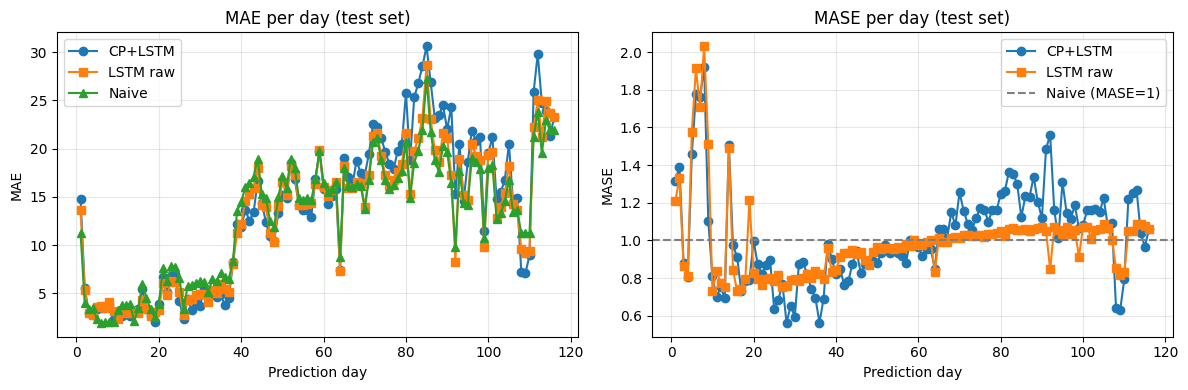

In [33]:
# Baseline: reshape learning tensor to (N_L, F*T), predict next N_P rows
X_flat_learn = X_learn.transpose(2, 0, 1).reshape(N_L, -1)  # (N_L, F*T)
dim_flat = X_flat_learn.shape[1]

class LSTMFlatPredictor(nn.Module):
    def __init__(self, dim_in, seq_len, pred_len, hidden=128):
        super().__init__()
        self.lstm = nn.LSTM(dim_in, hidden, num_layers=2, batch_first=True)
        self.fc = nn.Linear(hidden, pred_len * dim_in)
        self.pred_len = pred_len
        self.dim_in = dim_in
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        y = self.fc(last)
        return y.view(-1, self.pred_len, self.dim_in)

seq_len_flat = min(14, N_L - N_P)
if seq_len_flat < 1:
    seq_len_flat = 1
X_flat_seq = np.array([X_flat_learn[i - seq_len_flat : i] for i in range(seq_len_flat, N_L - N_P + 1)], dtype=np.float32)
Y_flat_seq = np.array([X_flat_learn[i : i + N_P] for i in range(seq_len_flat, N_L - N_P + 1)], dtype=np.float32)

if len(X_flat_seq) >= 2:
    model_flat = LSTMFlatPredictor(dim_flat, seq_len_flat, N_P, hidden=128).to(device)
    opt_flat = torch.optim.Adam(model_flat.parameters(), lr=1e-3)
    n_tr = len(X_flat_seq)
    for epoch in tqdm(range(epochs), desc="LSTM on raw (baseline)"):
        model_flat.train()
        perm = np.random.permutation(n_tr)
        for start in range(0, n_tr, batch):
            idx = perm[start : start + batch]
            x = torch.from_numpy(X_flat_seq[idx]).to(device)
            y = torch.from_numpy(Y_flat_seq[idx]).to(device)
            pred = model_flat(x)
            loss = nn.functional.mse_loss(pred, y)
            opt_flat.zero_grad()
            loss.backward()
            opt_flat.step()

    model_flat.eval()
    with torch.no_grad():
        inp_flat = torch.from_numpy(X_flat_learn[-seq_len_flat:].astype(np.float32)).unsqueeze(0).to(device)
        X_flat_pred = model_flat(inp_flat).cpu().numpy().squeeze(0)  # (N_P, F*T)

    X_pred_flat_recon = X_flat_pred.reshape(N_P, F, T).transpose(1, 2, 0)  # (F, T, N_P)
    num_flat = np.sum((X_pred_true - X_pred_flat_recon) ** 2)
    den_baseline = np.sum(X_pred_true ** 2) + 1e-12
    e_p_flat = np.sqrt(num_flat / den_baseline)
    mae_flat = np.mean(np.abs(X_pred_true - X_pred_flat_recon))
    print("LSTM on raw (no CP) baseline:")
    print(f"  Normalized prediction error e_p = {e_p_flat:.6f} ({100*e_p_flat:.2f}%)")
    print(f"  MAE = {mae_flat:.4f}")

    # Final comparison: CP+LSTM vs LSTM raw vs Naive (same style as time_series_8)
    if HAS_TENSORLY and "e_p" in dir() and "e_p_naive" in dir():
        print("Comparison: CP+LSTM vs LSTM raw vs Naive")
        print(f"  e_p:   CP+LSTM = {e_p:.6f},  LSTM raw = {e_p_flat:.6f},  Naive = {e_p_naive:.6f}")
        print(f"  MAE:   CP+LSTM = {mae:.4f},  LSTM raw = {mae_flat:.4f},  Naive = {mae_naive:.4f}")

        # MAE and MASE per prediction day (like ts8 Fig: MAE per step, MASE per step)
        import matplotlib.pyplot as plt
        maes_cp = [float(np.mean(np.abs(X_pred_true[:, :, d] - X_pred_recon[:, :, d]))) for d in range(N_P)]
        maes_flat_d = [float(np.mean(np.abs(X_pred_true[:, :, d] - X_pred_flat_recon[:, :, d]))) for d in range(N_P)]
        maes_naive_d = [float(np.mean(np.abs(X_pred_true[:, :, d] - X_naive_pred[:, :, d]))) for d in range(N_P)]
        mase_cp = [maes_cp[d] / (maes_naive_d[d] + 1e-12) for d in range(N_P)]
        mase_flat = [maes_flat_d[d] / (maes_naive_d[d] + 1e-12) for d in range(N_P)]
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        days = range(1, N_P + 1)
        ax1.plot(days, maes_cp, "o-", label="CP+LSTM")
        ax1.plot(days, maes_flat_d, "s-", label="LSTM raw")
        ax1.plot(days, maes_naive_d, "^-", label="Naive")
        ax1.set_xlabel("Prediction day")
        ax1.set_ylabel("MAE")
        ax1.set_title("MAE per day (test set)")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax2.plot(days, mase_cp, "o-", label="CP+LSTM")
        ax2.plot(days, mase_flat, "s-", label="LSTM raw")
        ax2.axhline(1.0, color="gray", linestyle="--", label="Naive (MASE=1)")
        ax2.set_xlabel("Prediction day")
        ax2.set_ylabel("MASE")
        ax2.set_title("MASE per day (test set)")
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()